In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.linewidth': 1.2,
    'grid.alpha': 0.4,
    'figure.dpi': 150
})

In [2]:
def j0_sinc(x):
    """
    Calcula la función sinc(x) = sin(x)/x de forma vectorizada y segura.
    Evita la división por cero en x=0 asignando el límite matemático 1.
    """
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(np.abs(x) < 1e-12, 1.0, np.sin(x) / x)

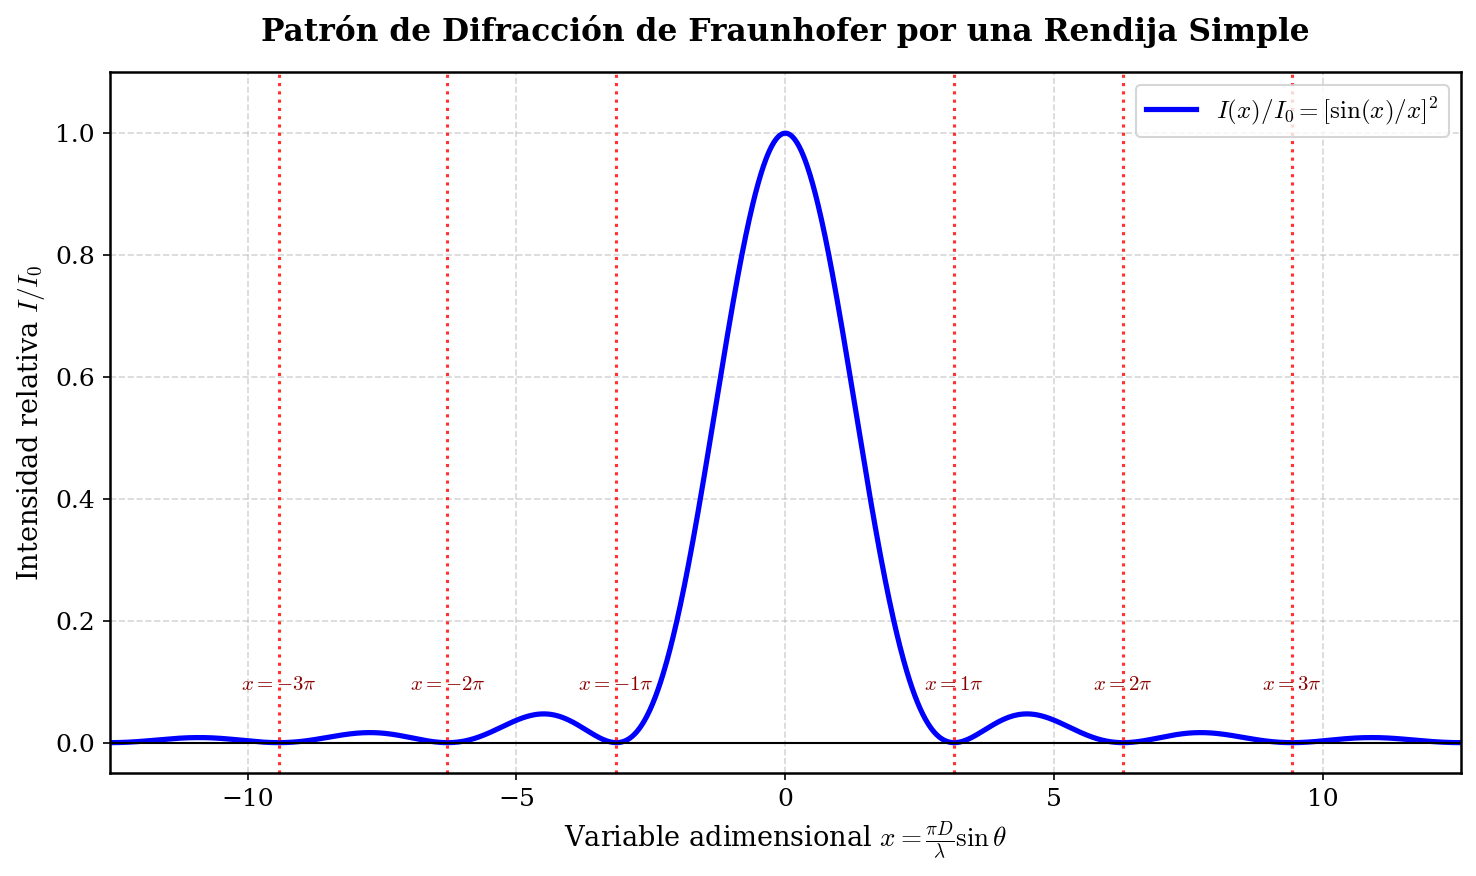

In [4]:
# =============================================================================
# GRÁFICO 1: Patrón de intensidad y localización de los mínimos de difracción
# =============================================================================
fig1, ax1 = plt.subplots(figsize=(10, 6))

x = np.linspace(-4*np.pi, 4*np.pi, 2000)
I = j0_sinc(x)**2

ax1.plot(x, I, 'b-', linewidth=2.5, label=r'$I(x)/I_0 = [\sin(x)/x]^2$')
ax1.axhline(0, color='black', linewidth=1)
ax1.set_xlabel(r'Variable adimensional $x = \frac{\pi D}{\lambda} \sin\theta$', fontsize=13)
ax1.set_ylabel(r'Intensidad relativa $I/I_0$', fontsize=13)
ax1.set_title('Patrón de Difracción de Fraunhofer por una Rendija Simple', fontsize=15, fontweight='bold', pad=15)
ax1.set_ylim(-0.05, 1.1)
ax1.set_xlim(-4*np.pi, 4*np.pi)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right', fontsize=12)

# Marcar los ceros de la función (mínimos de difracción)
n_vals = [-3, -2, -1, 1, 2, 3]
for n in n_vals:
    xm = n * np.pi
    ax1.axvline(xm, color='r', linestyle=':', linewidth=1.5, alpha=0.8)
    ax1.annotate(f'$x={n}\\pi$', xy=(xm, 0.08), ha='center', va='bottom', fontsize=10, color='darkred')

plt.tight_layout()
plt.savefig('grafico1_intensidad_difraccion.png', dpi=300)
plt.show()


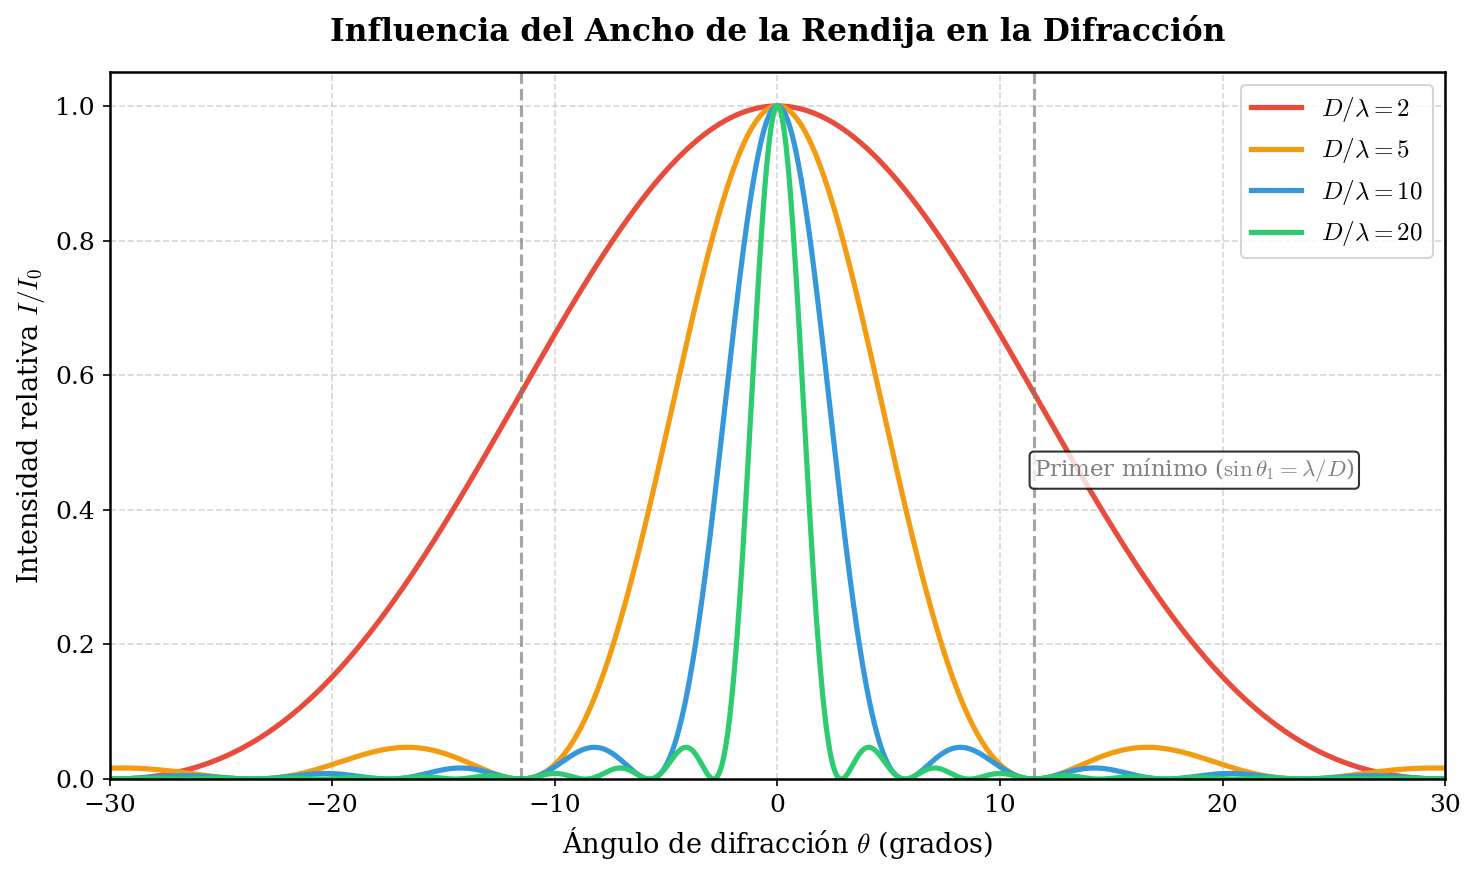

In [5]:
# =============================================================================
# GRÁFICO 2: Efecto del tamaño de la rendija (relación D/λ)
# =============================================================================
fig2, ax2 = plt.subplots(figsize=(10, 6))

theta_deg = np.linspace(-30, 30, 1500)
theta_rad = np.radians(theta_deg)

ratios = [2, 5, 10, 20]
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
labels = [r'$D/\lambda = 2$', r'$D/\lambda = 5$', r'$D/\lambda = 10$', r'$D/\lambda = 20$']

for ratio, color, label in zip(ratios, colors, labels):
    x = np.pi * ratio * np.sin(theta_rad)
    I = j0_sinc(x)**2
    ax2.plot(theta_deg, I, color=color, linewidth=2.5, label=label)

ax2.set_xlabel(r'Ángulo de difracción $\theta$ (grados)', fontsize=13)
ax2.set_ylabel(r'Intensidad relativa $I/I_0$', fontsize=13)
ax2.set_title('Influencia del Ancho de la Rendija en la Difracción', fontsize=15, fontweight='bold', pad=15)
ax2.set_xlim(-30, 30)
ax2.set_ylim(0, 1.05)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(fontsize=12, loc='upper right')

# Línea del primer mínimo para el caso D/λ = 5
theta1 = np.degrees(np.arcsin(1/5))
ax2.axvline(theta1, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axvline(-theta1, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.annotate(r'Primer mínimo ($\sin\theta_1 = \lambda/D$)', xy=(theta1, 0.45), fontsize=11,
             ha='left', color='gray',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig('grafico2_efecto_ancho_rendija.png', dpi=300)
plt.show()